In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from sklearn.metrics import r2_score
from matplotlib.lines import Line2D
from scipy.fft import fft, fftfreq
import xarray as xr

sys.path.append('/Users/kjesta/Desktop/LABDATA/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Probe_analysis')

from funcs import *
from processing_funcs import *
from analysis_funcs import *

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])

import warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

# For plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as mplstyle
mplstyle.use(['ggplot', 'fast'])

mpl.rcParams['figure.dpi'] = 200
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.titlesize'] = 14
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12

from matplotlib.transforms import ScaledTranslation
from matplotlib.colors import LinearSegmentedColormap
from cmocean import cm as cmo
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize

In [4]:
f14a03r1 = xr.open_dataset('/Users/kjesta/Desktop/LABDATA/PIV/Results/zoom/Final/f14a03_rec_res_r1.nc')
f14a03r2 = xr.open_dataset('/Users/kjesta/Desktop/LABDATA/PIV/Results/zoom/Final/f14a03_rec_res_r2.nc')
f14a03r3 = xr.open_dataset('/Users/kjesta/Desktop/LABDATA/PIV/Results/zoom/Final/f14a03_rec_res_r3.nc')

f14a02r1 = xr.open_dataset('/Users/kjesta/Desktop/LABDATA/PIV/Results/zoom/Final/f14a02_rec_res_r1.nc')
f14a02r2 = xr.open_dataset('/Users/kjesta/Desktop/LABDATA/PIV/Results/zoom/Final/f14a02_rec_res_r2.nc')
f14a02r3 = xr.open_dataset('/Users/kjesta/Desktop/LABDATA/PIV/Results/zoom/Final/f14a02_rec_res_r3.nc')

f14a01r1 = xr.open_dataset('/Users/kjesta/Desktop/LABDATA/PIV/Results/zoom/Final/f14a01_rec_res_r1.nc')
f14a01r2 = xr.open_dataset('/Users/kjesta/Desktop/LABDATA/PIV/Results/zoom/Final/f14a01_rec_res_r2.nc')
f14a01r3 = xr.open_dataset('/Users/kjesta/Desktop/LABDATA/PIV/Results/zoom/Final/f14a01_rec_res_r3.nc')

In [6]:
x = f14a03r1.x.values
z = f14a03r1.z.values

TypeError: Dimensions of C (50, 76) should be one smaller than X(50) and Y(76) while using shading='flat' see help(pcolormesh)

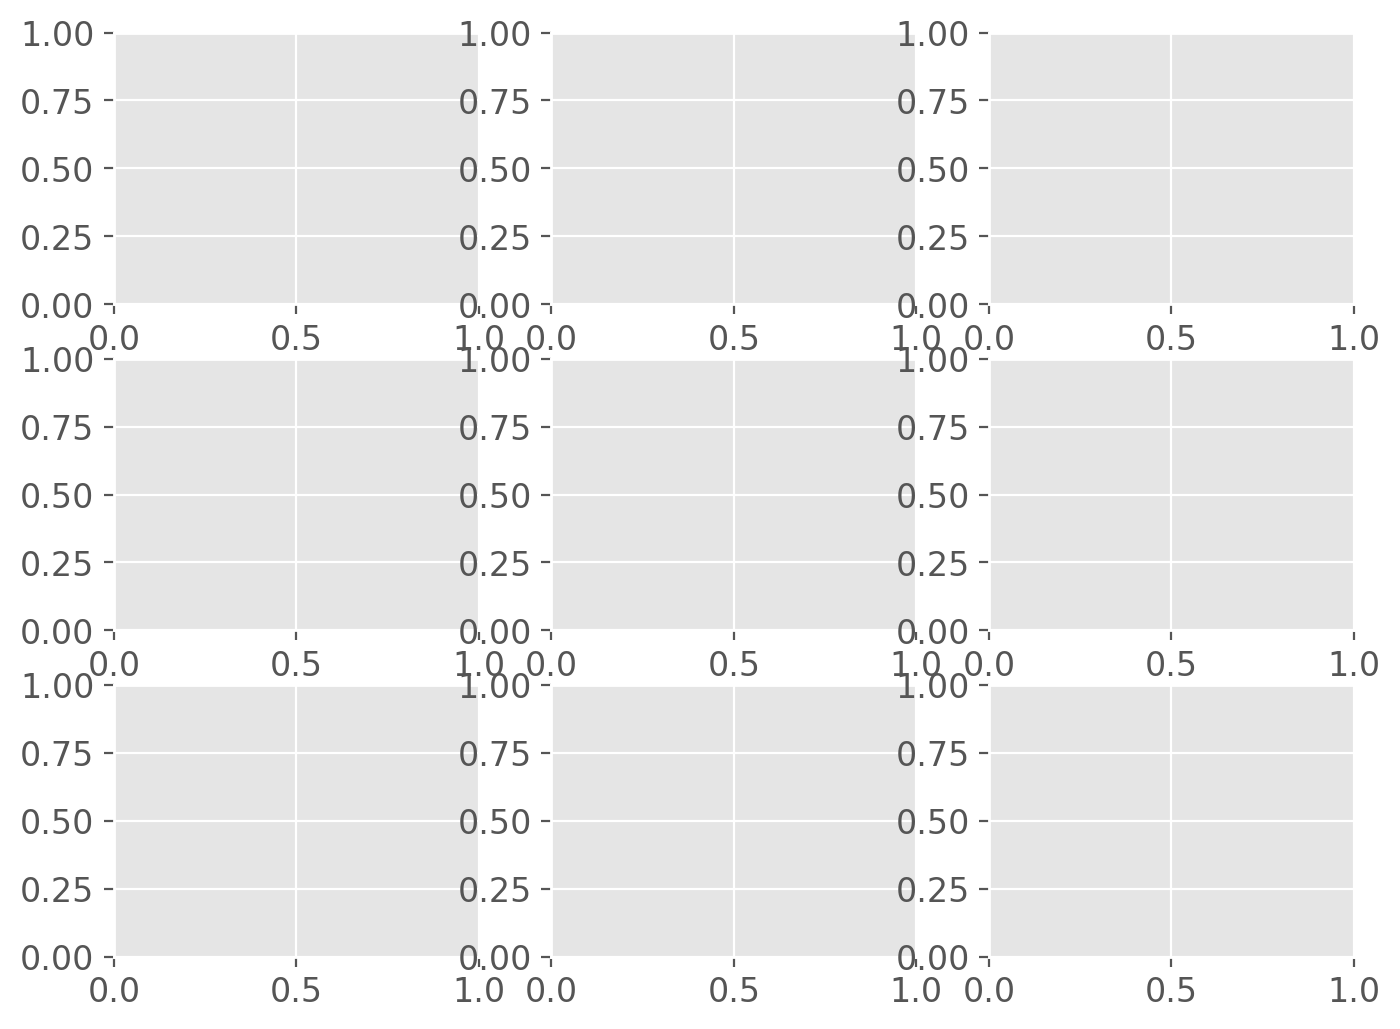

In [12]:
# Decimal for colorbars
from matplotlib import cm

kwargs = {'format': '%.3f'}

# Plot the velocity field
fig, ax = plt.subplots(3, 3, figsize=(8,6))

# Colorbar limits for velocity magnitude
umin = 0
umax = 0.03

# Subsampling steps for quiver plot
step_x = 2
step_z = 4

ax[0,0].pcolormesh(f14a03r1.z, f14a03r1.x, np.sqrt(f14a03r1.u[0, :, :]**2 + f14a03r1.w[0, :, :]**2), shading='auto', cmap=cmo.speed, vmin=umin, vmax=umax)






In [ ]:

   
# Plot the vorticity and velocity gradients
vmin = -0.005
vmax = 0.005
vlev = np.linspace(vmin, vmax, 41)

umin = -0.005
umax = 0.005
ulev = np.linspace(umin, umax, 41)

wmin = -0.005
wmax = 0.005
wlev = np.linspace(wmin, wmax, 41)

# Vorticity
fig, ax = plt.subplots(3, 1, figsize=(8,8))
im = ax[0].contourf(x, y, curl, alpha=0.6, levels=vlev, cmap=cm.vik, extend='both')
ax[0].imshow(enhanced_frames[key+1], cmap='gray_r', alpha=0.6, extent=(x.min(), x.max(), y.max(), y.min()))
cbar = plt.colorbar(im, ax=ax[0], label='Vorticity [1/s]', pad=0.01, shrink=0.9, **kwargs)
ax[0].grid()
ax[0].hlines(y=plate_top_m, xmin=x.min(), xmax=x.max(), colors='black', linestyles='--', linewidth=1, label='Top of plates')

# Velocity gradients
im = ax[1].contourf(x, y, grad_u, alpha=0.6, levels=ulev, cmap=cm.vik, extend='both')
cbar = plt.colorbar(im, ax=ax[1], label=r'$\partial u / \partial x$ [1/s]', pad=0.01, shrink=0.9, **kwargs)
ax[1].imshow(enhanced_frames[key+1], cmap='gray_r', alpha=0.6, extent=(x.min(), x.max(), y.max(), y.min()))
ax[1].grid()
ax[1].hlines(y=plate_top_m, xmin=x.min(), xmax=x.max(), colors='black', linestyles='--', linewidth=1, label='Top of plates')

im = ax[2].contourf(x, y, grad_w, alpha=0.6, levels=wlev, cmap=cm.vik, extend='both')
cbar = plt.colorbar(im, ax=ax[2], label=r'$\partial w / \partial z$ [1/s]', pad=0.01, shrink=0.9, **kwargs)
ax[2].imshow(enhanced_frames[key+1], cmap='gray_r', alpha=0.6, extent=(x.min(), x.max(), y.max(), y.min()))
ax[2].grid()
ax[2].hlines(y=plate_top_m, xmin=x.min(), xmax=x.max(), colors='black', linestyles='--', linewidth=1, label='Top of plates')
fig.suptitle(f't = {timestamps[idx_b]:.3f} s')

for a in ax:
a.xaxis.set_major_formatter(FuncFormatter(x_phys_formatter))
a.set_xlabel("x [m]")
a.yaxis.set_major_formatter(FuncFormatter(depth_formatter))
a.set_ylabel("z [m]")

plt.tight_layout() 